# Question 1

### Import

In [28]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader,random_split
import matplotlib.pyplot as plt


## Data generalization class

In [29]:
torch.manual_seed(21)

In [30]:
class Data_generation:
    def __init__(self,s: float, sample_n: int,equal_pick: bool):
        """
        Args:
            s (float): user-defined standard deviation.
            sample_n: sample number
            p_ratio: partion ratio for train set,validation set and test set
        """
        self.s = s
        self.sample_n = sample_n
        
        #Generate data points automatically
        if equal_pick:
            self.x1_x2, self.y = self.generate_DataPoints_equal()
        else:
            self.x1_x2, self.y = self.generate_DataPoints_notequal()
    
    
    #generate xor dataset
    def generate_DataPoints_notequal(self):
        ##Generate m1 and m2 simultaneously with equal probability
        m1_m2_set = torch.tensor([(0, 0), (0, 1), (1, 0), (1, 1)])
        random_index = torch.randint(0, len(m1_m2_set), (self.sample_n,)) ##how to make sure choose with equal probability
        m1_m2_term = m1_m2_set[random_index]
        #Generate random factor multiple user defined standard deviation
        noise_term = torch.normal(mean=0, std=1, size=(self.sample_n, 2)) * self.s
        #dataset for x1 and x2 
        x1_x2 = m1_m2_term + noise_term
        #dataset for y:
        y = (m1_m2_term[:, 0] ^ m1_m2_term[:, 1]).unsqueeze(1).float()
        return x1_x2,y
    
    def generate_DataPoints_equal(self):
        ##Generate m1 and m2 simultaneously with equal probability
        m1_m2_set = torch.tensor([(0, 0), (0, 1), (1, 0), (1, 1)])
        num_clusters = len(m1_m2_set)
        # Calculate the number of samples per cluster
        samples_per_cluster = self.sample_n // num_clusters

        # Create indices with equal numbers for each cluster
        random_index = torch.arange(num_clusters).repeat_interleave(samples_per_cluster)

        # Handle remainder if sample_n is not divisible by num_clusters
        remainder = self.sample_n % num_clusters
        if remainder > 0:
            additional_indices = torch.randint(0, num_clusters, (remainder,))
            random_index = torch.cat((random_index, additional_indices))

        # Shuffle the indices
        random_index = random_index[torch.randperm(len(random_index))]

        # Map indices to m1_m2_set
        m1_m2_term = m1_m2_set[random_index]

        #Generate random factor multiple user defined standard deviation
        noise_term = torch.normal(mean=0, std=1, size=(self.sample_n, 2)) * self.s
        #dataset for x1 and x2 
        x1_x2 = m1_m2_term + noise_term
        #dataset for y:
        y = (m1_m2_term[:, 0] ^ m1_m2_term[:, 1]).unsqueeze(1).float()
        return x1_x2,y
    

    def __len__(self):
        """
        Returns the total number of samples. from ChatGPT
        """
        return self.sample_n

    def __getitem__(self, idx):
        """
        Retrieves a single sample by index. from ChatGPT
        Args:
            idx (int): Index of the sample.
        Returns:
            x (torch.Tensor): Features of shape (2,).
            y (torch.Tensor): Label (scalar).
        """
        return self.x1_x2[idx], self.y[idx]
    

In [31]:
dataset = Data_generation(s=0.5,sample_n=1000,equal_pick=True)

In [32]:
# Define split ratios
train_ratio = 0.7
val_ratio = 0.2
test_ratio = 0.1

# Calculate sizes of each split
total_samples = len(dataset)
train_size = int(train_ratio * total_samples)
val_size = int(val_ratio * total_samples)
test_size = total_samples - train_size - val_size  # Ensure no samples are lost

# Split the dataset
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# Create DataLoaders for each split
train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=10, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)

print(f"Training dataset length = {len(train_dataset)}")
print(f"Validation dataset length = {len(val_dataset)}")
print(f"Test dataset length = {len(test_dataset)}")

Training dataset length = 700
Validation dataset length = 200
Test dataset length = 100


## Model class

In [33]:
# Define the network using nn.Sequential
class FeedForwardNN(nn.Module):
    def __init__(self):
        super(FeedForwardNN, self).__init__() #Calls the parent class (nn.Module) initializer to properly set up the class.
        self.model = nn.Sequential(
            nn.Linear(2, 3),   # Input layer: 2 input features -> 3 hidden features
            nn.Tanh(),         # Activation: Tanh
            nn.Linear(3, 1),   # Output layer: 3 hidden features -> 1 output feature
            nn.Identity(),      # Activation: Identity function (no-op)
        )

    def forward(self, x):
        return self.model(x)

## Initialized model

In [34]:
# Initialize the model
model = FeedForwardNN()
print(model)

FeedForwardNN(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=3, bias=True)
    (1): Tanh()
    (2): Linear(in_features=3, out_features=1, bias=True)
    (3): Identity()
  )
)


## Define Loss function and optimizer

In [35]:

# Define the binary cross-entropy loss function
loss_fn = nn.BCEWithLogitsLoss()  # Combines sigmoid and BCE
# loss_fn = nn.BCELoss() #only BCE function plus sigmoid() in last layer

# Example optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
#optimizer = torch.optim.SGD(model.parameters(),lr=0.01, momentum=0.9)

## Training loop

In [36]:
def train_one_epoch(model, train_loader, loss_fn, optimizer):
    """
    Trains the model for one epoch and calculates average training loss and accuracy.

    Args:
        model (nn.Module): The model to train.
        train_loader (DataLoader): DataLoader for the training dataset.
        loss_fn (nn.Module): Loss function (e.g., BCEWithLogitsLoss).
        optimizer (torch.optim.Optimizer): Optimizer to update model parameters.

    Returns:
        tuple: Average training loss and training accuracy for the epoch.
    """
    model.train()  # Set the model to training mode
    epoch_loss = 0  # Track training loss
    correct = 0  # Track number of correct predictions
    total = 0  # Track total number of samples

    for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
        # Forward pass
        predictions = model(x_batch)

        # Compute the loss
        loss = loss_fn(predictions, y_batch)

        # Backward pass
        optimizer.zero_grad()  # Reset gradients
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights

        # Accumulate loss
        epoch_loss += loss.item()

        # Calculate accuracy for this batch
        # Apply sigmoid to convert logits to probabilities
        probabilities = torch.sigmoid(predictions)
        predicted_classes = (probabilities > 0.5).int()  # Threshold at 0.5
        correct += (predicted_classes == y_batch).sum().item()
        total += y_batch.size(0)  # Update total number of samples

    # Calculate average loss and accuracy
    avg_loss = epoch_loss / len(train_loader)  # Average training loss
    accuracy = correct / total  # Training accuracy as a percentage

    return avg_loss, accuracy


# Function to evaluate the model on validation data
def evaluate_with_accuracy(model, val_loader, loss_fn):
    """
    Evaluates the model on the validation dataset and calculates validation loss and accuracy.
    
    Args:
        model (nn.Module): The trained model.
        val_loader (DataLoader): DataLoader for the validation dataset.
        loss_fn (nn.Module): Loss function (e.g., BCEWithLogitsLoss).
    
    Returns:
        tuple: Average validation loss and accuracy.
    """
    model.eval()  # Set the model to evaluation mode
    val_loss = 0  # Track validation loss
    correct = 0  # Track number of correct predictions
    total = 0  # Track total number of samples
    
    with torch.no_grad():  # No gradient computation for validation
        for x_batch, y_batch in val_loader:
            # Forward pass
            predictions = model(x_batch)
            
            # Compute loss
            loss = loss_fn(predictions, y_batch)
            val_loss += loss.item()
            
            # Compute accuracy
            # Apply sigmoid to convert logits to probabilities
            probabilities = torch.sigmoid(predictions)
            predicted_classes = (probabilities > 0.5).int()  # Threshold at 0.5
            correct += (predicted_classes == y_batch).sum().item()
            total += y_batch.size(0)  # Update total number of samples
    
    # Calculate average loss and accuracy
    avg_loss = val_loss / len(val_loader)  # Average validation loss
    accuracy = correct / total  # Accuracy as a percentage
    return avg_loss, accuracy


# Training loop with validation
n_epochs = 20
train_losses = []  # Store training losses for each epoch
train_accuracy_for_each_epoch = [] # store training accuracy for each epoch
val_losses = []  # Store validation losses for each epoch 
val_accuracy= []#Store accuracy for each epoch 

for epoch in range(n_epochs):
    # Train for one epoch
    train_output = train_one_epoch(model, train_loader, loss_fn, optimizer)
    train_losses.append(train_output[0])
    train_accuracy_for_each_epoch.append(train_output[1])

    # Evaluate on validation data
    val_output = evaluate_with_accuracy(model, val_loader, loss_fn)
    val_losses.append(val_output[0])
    val_accuracy.append(val_output[1])

    # Print losses for the current epoch
    print(f"Epoch {epoch + 1}/{n_epochs}, Train Loss: {train_output[0]:.4f},train Accuracy: {train_output[1]:.4f}， Validation Loss: {val_output[0]:.4f},Validation Accuracy: {val_output[1]:.4f}")

# Optionally, return or store train_losses and val_losses for further analysis


Epoch 1/20, Train Loss: 0.7003,train Accuracy: 0.4686， Validation Loss: 0.6912,Validation Accuracy: 0.5750
Epoch 2/20, Train Loss: 0.6886,train Accuracy: 0.5843， Validation Loss: 0.6871,Validation Accuracy: 0.5600
Epoch 3/20, Train Loss: 0.6819,train Accuracy: 0.5857， Validation Loss: 0.6768,Validation Accuracy: 0.6450
Epoch 4/20, Train Loss: 0.6692,train Accuracy: 0.6386， Validation Loss: 0.6659,Validation Accuracy: 0.6300
Epoch 5/20, Train Loss: 0.6567,train Accuracy: 0.6386， Validation Loss: 0.6524,Validation Accuracy: 0.6450
Epoch 6/20, Train Loss: 0.6439,train Accuracy: 0.6643， Validation Loss: 0.6430,Validation Accuracy: 0.6650
Epoch 7/20, Train Loss: 0.6325,train Accuracy: 0.6800， Validation Loss: 0.6365,Validation Accuracy: 0.6600
Epoch 8/20, Train Loss: 0.6271,train Accuracy: 0.6743， Validation Loss: 0.6317,Validation Accuracy: 0.6450
Epoch 9/20, Train Loss: 0.6151,train Accuracy: 0.6814， Validation Loss: 0.6219,Validation Accuracy: 0.6850
Epoch 10/20, Train Loss: 0.6059,train

## Visualization 

#### Validation accuracy and train accuracy

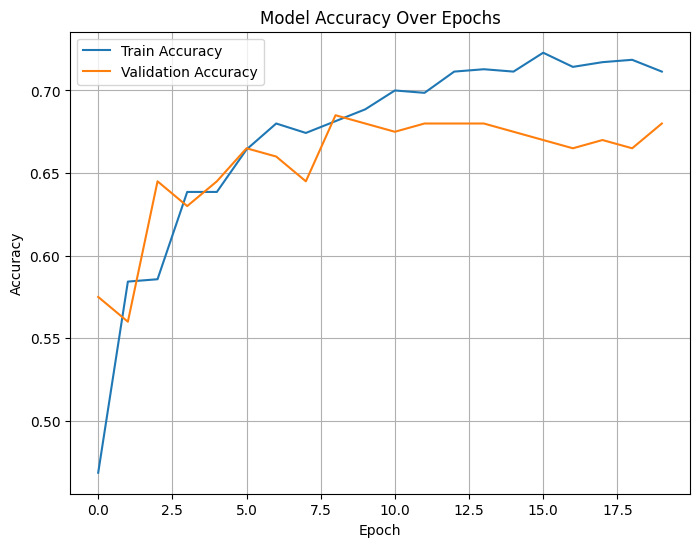

In [37]:
def plot_accuracies(train_accuracies, val_accuracies, title="Training and Validation Accuracy"):
    """
    Plots training and validation accuracies over epochs.
    
    Args:
        train_accuracies (list or array-like): List of training accuracies for each epoch.
        val_accuracies (list or array-like): List of validation accuracies for each epoch.
        title (str): Title of the plot (default: "Training and Validation Accuracy").
    """
    plt.figure(figsize=(8, 6))
    plt.plot(range(len(train_accuracies)), train_accuracies, label="Train Accuracy")
    plt.plot(range(len(val_accuracies)), val_accuracies, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()
# Example usage
plot_accuracies(train_accuracy_for_each_epoch , val_accuracy, title="Model Accuracy Over Epochs")


#### Train loss and validation loss for each epoch

In [38]:
def plot_losses(train_losses, val_losses, title="Training and Validation Loss"):
    """
    Plots training and validation losses over epochs.
    
    Args:
        train_losses (list or array-like): List of training losses for each epoch.
        val_losses (list or array-like): List of validation losses for each epoch.
        title (str): Title of the plot (default: "Training and Validation Loss").
    """
    plt.figure(figsize=(8, 6))
    plt.plot(range(len(train_losses)), train_losses, label="Train Loss")
    plt.plot(range(len(val_losses)), val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

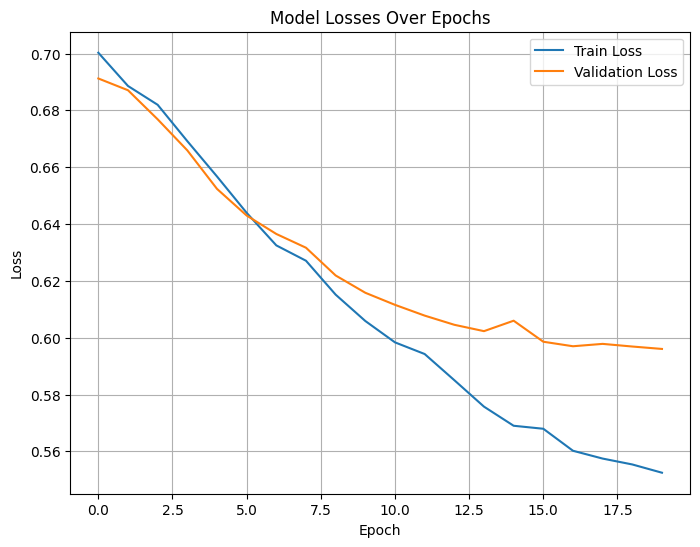

In [39]:
# Example: Plot losses
plot_losses(train_losses, val_losses, title="Model Losses Over Epochs")


## Plot the dataset from the loaders before training

In [40]:
def plot_dataset_from_loaders(train_loader, val_loader, title="Training and Validation Dataset"):
    """
    Plots the training and validation datasets with class labels from DataLoaders.
    
    Args:
        train_loader (DataLoader): DataLoader for the training dataset.
        val_loader (DataLoader): DataLoader for the validation dataset.
        title (str): Title of the plot (default: "Training and Validation Dataset").
    """
    def extract_data(loader):
        # Helper function to extract all data and labels from a DataLoader
        features = []
        labels = []
        for batch in loader:
            x_batch, y_batch = batch
            features.append(x_batch)
            labels.append(y_batch)
        return torch.cat(features), torch.cat(labels)
    
    # Extract features and labels from loaders
    train_data, train_labels = extract_data(train_loader)
    val_data, val_labels = extract_data(val_loader)
    
    # Convert labels to 1D if necessary
    train_labels = train_labels.squeeze()
    val_labels = val_labels.squeeze()
    
    # Create the scatter plot
    plt.figure(figsize=(10, 8))
    
    # Training set
    plt.scatter(train_data[train_labels == 0][:, 0], train_data[train_labels == 0][:, 1], 
                label="Train Class 0", alpha=0.7, marker='o')
    plt.scatter(train_data[train_labels == 1][:, 0], train_data[train_labels == 1][:, 1], 
                label="Train Class 1", alpha=0.7, marker='^')

    # Validation set
    plt.scatter(val_data[val_labels == 0][:, 0], val_data[val_labels == 0][:, 1], 
                label="Val Class 0", alpha=0.7, marker='x')
    plt.scatter(val_data[val_labels == 1][:, 0], val_data[val_labels == 1][:, 1], 
                label="Val Class 1", alpha=0.7, marker='s')
    
    # Labels and legend
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

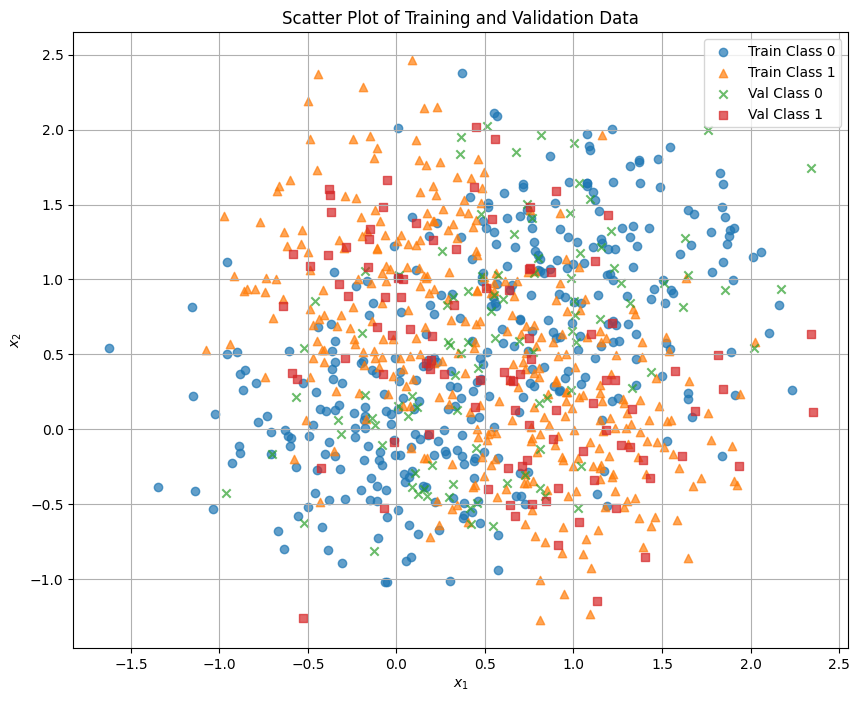

In [41]:
plot_dataset_from_loaders(train_loader, val_loader, title="Scatter Plot of Training and Validation Data")

## How well the test set should be ?

In [42]:
def plot_test_set_reactions_with_accuracy_and_loss(test_loader, model, loss_fn, title="Test Set Reactions"):
    """
    Visualizes the test set reactions by plotting actual classes and model predictions,
    and calculates and displays the test accuracy and average test loss on the plot.
    
    Args:
        test_loader (DataLoader): DataLoader for the test dataset.
        model (nn.Module): Trained PyTorch model.
        loss_fn (nn.Module): Loss function (e.g., BCEWithLogitsLoss).
        title (str): Title of the plot (default: "Test Set Reactions").
    """
    def extract_data(loader):
        # Helper function to extract all data and labels from a DataLoader
        features = []
        labels = []
        for batch in loader:
            x_batch, y_batch = batch
            features.append(x_batch)
            labels.append(y_batch)
        return torch.cat(features), torch.cat(labels)
    
    # Extract features and labels from the test loader
    test_data, test_labels = extract_data(test_loader)

    # Set the model to evaluation mode
    model.eval()
    
    test_loss = 0.0  # Initialize test loss
    with torch.no_grad():
        # Get predictions for the test data
        logits = model(test_data)
        probabilities = torch.sigmoid(logits).squeeze()  # Convert logits to probabilities
        predictions = (probabilities > 0.5).int()  # Convert to binary predictions (0 or 1)
        
        # Calculate test accuracy
        correct = (predictions == test_labels.squeeze()).sum().item()
        total = test_labels.size(0)
        test_accuracy = correct / total  # Compute accuracy as a proportion
        
        # Calculate average test loss
        test_loss = loss_fn(logits, test_labels.float()).item()

    # Create the scatter plot
    plt.figure(figsize=(10, 8))
    
    # True classes
    plt.scatter(
        test_data[:, 0][(test_labels == 0).flatten()], 
        test_data[:, 1][(test_labels == 0).flatten()], 
        label="Test Class 0 (True)", alpha=0.7, marker='o', color="blue"
    )
    plt.scatter(
        test_data[:, 0][(test_labels == 1).flatten()], 
        test_data[:, 1][(test_labels == 1).flatten()], 
        label="Test Class 1 (True)", alpha=0.7, marker='^', color="orange"
    )

    # Predicted classes
    plt.scatter(
        test_data[:, 0][(predictions == 0).flatten()], 
        test_data[:, 1][(predictions == 0).flatten()], 
        label="Test Class 0 (Predicted)", alpha=0.3, marker='x', color="cyan"
    )
    plt.scatter(
        test_data[:, 0][(predictions == 1).flatten()], 
        test_data[:, 1][(predictions == 1).flatten()], 
        label="Test Class 1 (Predicted)", alpha=0.3, marker='s', color="red"
    )

    # Add test accuracy and loss annotation
    accuracy_text = f"Test Accuracy: {test_accuracy*100:.2f}%"
    loss_text = f"Average Test Loss: {test_loss:.4f}"
    plt.text(0.55, 0.55, accuracy_text, fontsize=12, color="black", transform=plt.gca().transAxes, 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))
    plt.text(0.45, 0.4, loss_text, fontsize=12, color="black", transform=plt.gca().transAxes, 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))
    
    # Labels and legend
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


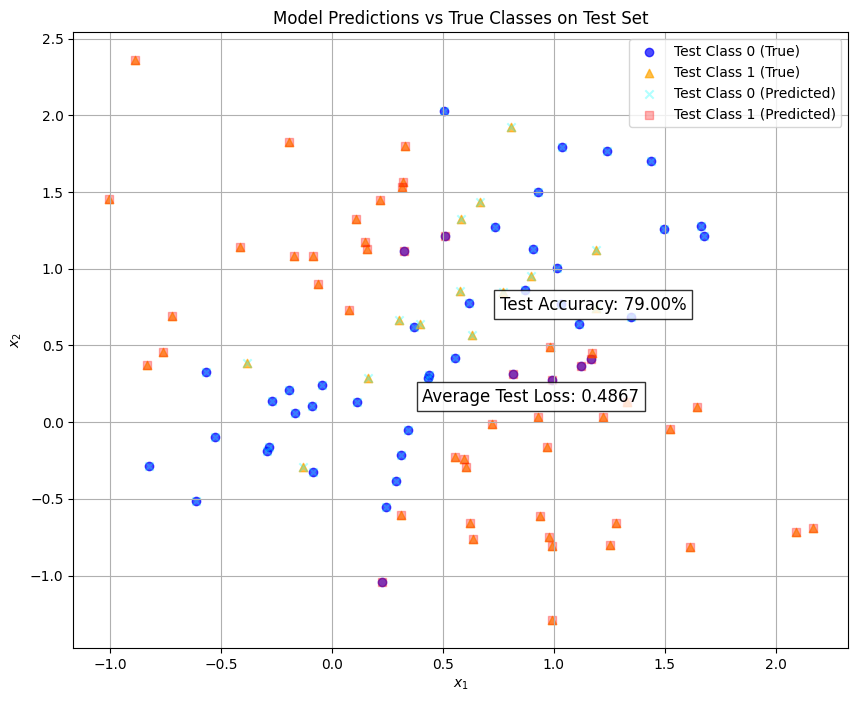

In [43]:
# Visualize test set reactions
plot_test_set_reactions_with_accuracy_and_loss(test_loader, model, loss_fn,title="Model Predictions vs True Classes on Test Set")


# QUESTION 2

#### import 

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader,random_split
import matplotlib.pyplot as plt

# torch.manual_seed(21)

## Data generation allow creating different dataset for each training

In [3]:
class Data_generation:
    def __init__(self,s: float, sample_n: int,equal_pick: bool):
        """
        Args:
            s (float): user-defined standard deviation.
            sample_n: sample number
            p_ratio: partion ratio for train set,validation set and test set
        """
        self.s = s
        self.sample_n = sample_n
        
        #Generate data points automatically
        if equal_pick:
            self.x1_x2, self.y = self.generate_DataPoints_equal()
        else:
            self.x1_x2, self.y = self.generate_DataPoints_notequal()
    
    
    #generate xor dataset
    def generate_DataPoints_notequal(self):
        ##Generate m1 and m2 simultaneously with equal probability
        m1_m2_set = torch.tensor([(0, 0), (0, 1), (1, 0), (1, 1)])
        random_index = torch.randint(0, len(m1_m2_set), (self.sample_n,)) ##how to make sure choose with equal probability
        m1_m2_term = m1_m2_set[random_index]
        #Generate random factor multiple user defined standard deviation
        noise_term = torch.normal(mean=0, std=1, size=(self.sample_n, 2)) * self.s
        #dataset for x1 and x2 
        x1_x2 = m1_m2_term + noise_term
        #dataset for y:
        y = (m1_m2_term[:, 0] ^ m1_m2_term[:, 1]).unsqueeze(1).float()
        return x1_x2,y
    
    def generate_DataPoints_equal(self):
        ##Generate m1 and m2 simultaneously with equal probability
        m1_m2_set = torch.tensor([(0, 0), (0, 1), (1, 0), (1, 1)])
        num_clusters = len(m1_m2_set)
        # Calculate the number of samples per cluster
        samples_per_cluster = self.sample_n // num_clusters

        # Create indices with equal numbers for each cluster
        random_index = torch.arange(num_clusters).repeat_interleave(samples_per_cluster)

        # Handle remainder if sample_n is not divisible by num_clusters
        remainder = self.sample_n % num_clusters
        if remainder > 0:
            additional_indices = torch.randint(0, num_clusters, (remainder,))
            random_index = torch.cat((random_index, additional_indices))

        # Shuffle the indices
        random_index = random_index[torch.randperm(len(random_index))]

        # Map indices to m1_m2_set
        m1_m2_term = m1_m2_set[random_index]

        #Generate random factor multiple user defined standard deviation
        noise_term = torch.normal(mean=0, std=1, size=(self.sample_n, 2)) * self.s
        #dataset for x1 and x2 
        x1_x2 = m1_m2_term + noise_term
        #dataset for y:
        y = (m1_m2_term[:, 0] ^ m1_m2_term[:, 1]).unsqueeze(1).float()
        return x1_x2,y
    

    def __len__(self):
        """
        Returns the total number of samples. from ChatGPT
        """
        return self.sample_n

    def __getitem__(self, idx):
        """
        Retrieves a single sample by index. from ChatGPT
        Args:
            idx (int): Index of the sample.
        Returns:
            x (torch.Tensor): Features of shape (2,).
            y (torch.Tensor): Label (scalar).
        """
        return self.x1_x2[idx], self.y[idx]
    
def prepare_dataloaders(dataset, train_ratio=0.7, val_ratio=0.2, test_ratio=0.1, batch_size=10):
    """
    Splits a dataset into training, validation, and test sets, and creates DataLoaders for each split.
    
    Args:
        dataset (torch.utils.data.Dataset): The dataset to be split.
        train_ratio (float): Proportion of the dataset to be used for training.
        val_ratio (float): Proportion of the dataset to be used for validation.
        test_ratio (float): Proportion of the dataset to be used for testing.
        batch_size (int): Batch size for the DataLoaders.
        
    Returns:
        dict: A dictionary containing DataLoaders for 'train', 'val', and 'test' splits.
    """
    # Ensure the ratios sum to 1
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, "Ratios must sum to 1."
    
    # Calculate sizes of each split
    total_samples = len(dataset)
    train_size = int(train_ratio * total_samples)
    val_size = int(val_ratio * total_samples)
    test_size = total_samples - train_size - val_size  # Ensure no samples are lost
    
    # Split the dataset
    train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])
    
    # Create DataLoaders for each split
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # Print dataset lengths
    print(f"Training dataset length = {len(train_dataset)}")
    print(f"Validation dataset length = {len(val_dataset)}")
    print(f"Test dataset length = {len(test_dataset)}")
    
    return {
        "train": train_loader,
        "val": val_loader,
        "test": test_loader
    }

## Set up multiple network configuration

In [4]:
# Define a function to create a feedforward network dynamically
def create_network(input_size, output_size, depth, width):
    """
    Dynamically creates a feedforward network with given depth and width.
    
    Args:
        input_size (int): Number of input features.
        output_size (int): Number of output features.
        depth (int): Number of hidden layers.
        width (int): Number of neurons per hidden layer.
        
    Returns:
        nn.Module: A feedforward neural network.
    """
    layers = []
    
    # Input layer
    layers.append(nn.Linear(input_size, width))
    layers.append(nn.Tanh())  # Use ReLU activation for hidden layers
    
    # Add hidden layers
    for _ in range(depth-1):  # (depth - 1) because the input layer already added
        layers.append(nn.Linear(width,width))
        layers.append(nn.Identity())
    
    # Output layer
    layers.append(nn.Linear(width, output_size))
    layers.append(nn.Identity())
    
    # No activation for the output layer (e.g., sigmoid will be applied during training for BCE loss)
    return nn.Sequential(*layers)



## Train loop function 

In [5]:
def train_one_epoch(model, train_loader, loss_fn, optimizer):
    """
    Trains the model for one epoch and calculates average training loss and accuracy.

    Args:
        model (nn.Module): The model to train.
        train_loader (DataLoader): DataLoader for the training dataset.
        loss_fn (nn.Module): Loss function (e.g., BCEWithLogitsLoss).
        optimizer (torch.optim.Optimizer): Optimizer to update model parameters.

    Returns:
        tuple: Average training loss and training accuracy for the epoch.
    """
    model.train()  # Set the model to training mode
    epoch_loss = 0  # Track training loss
    correct = 0  # Track number of correct predictions
    total = 0  # Track total number of samples

    for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
        # Forward pass
        predictions = model(x_batch)

        # Compute the loss
        loss = loss_fn(predictions, y_batch)

        # Backward pass
        optimizer.zero_grad()  # Reset gradients
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights

        # Accumulate loss
        epoch_loss += loss.item()

        # Calculate accuracy for this batch
        # Apply sigmoid to convert logits to probabilities
        probabilities = torch.sigmoid(predictions)
        predicted_classes = (probabilities > 0.5).int()  # Threshold at 0.5
        correct += (predicted_classes == y_batch).sum().item()
        total += y_batch.size(0)  # Update total number of samples

    # Calculate average loss and accuracy
    avg_loss = epoch_loss / len(train_loader)  # Average training loss
    accuracy = correct / total  # Training accuracy as a percentage

    return avg_loss, accuracy

# Function to evaluate the model on validation data and calculate loss standard deviation
def evaluate_with_loss_std(model, val_loader, loss_fn):
    """
    Evaluates the model on the validation dataset and calculates validation loss,
    accuracy, and the standard deviation of the loss.
    
    Args:
        model (nn.Module): The trained model.
        val_loader (DataLoader): DataLoader for the validation dataset.
        loss_fn (nn.Module): Loss function (e.g., BCEWithLogitsLoss).
    
    Returns:
        tuple: Average validation loss, accuracy, and standard deviation of the loss.
    """
    model.eval()  # Set the model to evaluation mode
    val_loss = 0  # Track validation loss
    correct = 0  # Track number of correct predictions
    total = 0  # Track total number of samples
    all_losses = []  # Store losses for standard deviation calculation
    
    with torch.no_grad():  # No gradient computation for validation
        for x_batch, y_batch in val_loader:
            # Forward pass
            predictions = model(x_batch)
            
            # Compute loss
            loss = loss_fn(predictions, y_batch)
            val_loss += loss.item()
            all_losses.append(loss.item())  # Append the loss for standard deviation
            
            # Compute accuracy
            # Apply sigmoid to convert logits to probabilities
            probabilities = torch.sigmoid(predictions)
            predicted_classes = (probabilities > 0.5).int()  # Threshold at 0.5
            correct += (predicted_classes == y_batch).sum().item()
            total += y_batch.size(0)  # Update total number of samples
    
    # Calculate average loss and accuracy
    avg_loss = val_loss / len(val_loader)  # Average validation loss
    accuracy = correct / total  # Accuracy as a percentage
    
    # Calculate standard deviation of the loss
    loss_std = torch.std(torch.tensor(all_losses))  # Convert to tensor for std calculation
    
    return avg_loss, accuracy, loss_std.item()




## Run before section

In [6]:
# Example: Setting up multiple configurations
input_size = 2  # For XOR problem (x1, x2)
output_size = 1  # Binary output (0 or 1)
depths = [0, 1, 2, 3]  # Number of hidden layers
widths = [1, 2, 3]  # Number of neurons per hidden layer

# Store configurations and models
network_configurations = []

for depth in depths:
    for width in widths:
        if depth == 0:
            # Logistic regression model (no hidden layers)
            model = nn.Sequential(nn.Linear(input_size, output_size))
        else:
            # Create a feedforward network with the specified depth and width
            model = create_network(input_size, output_size, depth, width)
        
        # Save the model and its configuration
        network_configurations.append({"depth": depth, "width": width, "model": model})

# Print the configurations
# for config in network_configurations:
#     print(f"Depth: {config['depth']}, Width: {config['width']}")
#     print(config['model'])

## Run

In [7]:
def count_parameters(model):
    """
    Counts the number of trainable parameters in a PyTorch model.
    
    Args:
        model (nn.Module): The model whose parameters are to be counted.
        
    Returns:
        int: The total number of trainable parameters.
    """
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Training loop with validation and test loss for multiple runs
n_epochs = 20
lr = 0.01
times = 20  # Number of runs for each configuration

# Initialize dictionary to store metrics for each configuration
metrics = {}

for config in network_configurations:
    model_depth = config['depth']
    model_width = config['width']
    
    # Store results for multiple runs
    test_losses = []
    test_accuracies = []
    
    print(f"Testing model with depth={model_depth}, width={model_width}")
    for run in range(times):
        dataset = Data_generation(s=0.1,sample_n=1000,equal_pick=True)
        # Prepare DataLoaders 
        loaders = prepare_dataloaders(dataset, train_ratio=0.7, val_ratio=0.2, test_ratio=0.1, batch_size=10)

        # Access the DataLoaders
        train_loader = loaders["train"]
        val_loader = loaders["val"]
        test_loader = loaders["test"]
        # Create a new model instance for each run
        model = config['model']
        
        # Define the binary cross-entropy loss function
        loss_fn = nn.BCEWithLogitsLoss()  # Combines sigmoid and BCE

        # Example optimizer
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        print(f"Run {run + 1}/{times} for depth={model_depth}, width={model_width}")
        for epoch in range(n_epochs):
            # Train for one epoch
            train_one_epoch(model, train_loader, loss_fn, optimizer)

        # After training, evaluate on the test set
        test_output = evaluate_with_loss_std(model, test_loader, loss_fn)
        test_losses.append(test_output[0])
        test_accuracies.append(test_output[1])

    # Count trainable parameters (same for all runs for this configuration)
    num_parameters = count_parameters(config['model'])

    # Store the full series of test losses and accuracies for this configuration
    metrics[(model_depth, model_width)] = {
        'test_losses': test_losses,
        'test_accuracies': test_accuracies,
        'num_parameters': num_parameters  # Add parameter count here
    }




Testing model with depth=0, width=1
Training dataset length = 700
Validation dataset length = 200
Test dataset length = 100
Run 1/20 for depth=0, width=1
Training dataset length = 700
Validation dataset length = 200
Test dataset length = 100
Run 2/20 for depth=0, width=1
Training dataset length = 700
Validation dataset length = 200
Test dataset length = 100
Run 3/20 for depth=0, width=1
Training dataset length = 700
Validation dataset length = 200
Test dataset length = 100
Run 4/20 for depth=0, width=1
Training dataset length = 700
Validation dataset length = 200
Test dataset length = 100
Run 5/20 for depth=0, width=1
Training dataset length = 700
Validation dataset length = 200
Test dataset length = 100
Run 6/20 for depth=0, width=1
Training dataset length = 700
Validation dataset length = 200
Test dataset length = 100
Run 7/20 for depth=0, width=1
Training dataset length = 700
Validation dataset length = 200
Test dataset length = 100
Run 8/20 for depth=0, width=1
Training dataset len

In [9]:
# # Print summary of metrics for each configuration
# print("\nSummary of Metrics (All Runs):")
# print(f"{'Depth':<10}{'Width':<10}{'Parameters':<15}{'Test Losses':<50}{'Test Accuracies'}")
# print("-" * 100)
# for (depth, width), data in metrics.items():
#     print(f"{depth:<10}{width:<10}{data['num_parameters']:<15}{str(data['test_losses']):<50}{str(data['test_accuracies'])}")

In [10]:
import math

print("\nSummary of Mean Test Metrics:")
print(f"{'Depth':<10}{'Width':<10}{'Parameters':<15}{'Mean Test Loss':<20}{'Test Loss Std Dev':<20}{'Mean Test Accuracy':<20}")
print("-" * 95)

for (depth, width), data in metrics.items():
    mean_test_loss = sum(data['test_losses']) / len(data['test_losses'])  # Calculate mean test loss
    mean_test_accuracy = sum(data['test_accuracies']) / len(data['test_accuracies'])  # Calculate mean test accuracy
    parameters = data.get('num_parameters', 'N/A')  # Get number of parameters if available

    # Calculate standard deviation of test losses
    variance = sum((x - mean_test_loss) ** 2 for x in data['test_losses']) / len(data['test_losses'])
    std_dev = math.sqrt(variance)

    print(f"{depth:<10}{width:<10}{parameters:<15}{mean_test_loss:<20.4f}{std_dev:<20.4f}{mean_test_accuracy:<20.4f}")



Summary of Mean Test Metrics:
Depth     Width     Parameters     Mean Test Loss      Test Loss Std Dev   Mean Test Accuracy  
-----------------------------------------------------------------------------------------------
0         1         3              0.6970              0.0042              0.4620              
0         2         3              0.6994              0.0054              0.4695              
0         3         3              0.6960              0.0039              0.4830              
1         1         5              0.4716              0.0419              0.7580              
1         2         9              0.3547              0.0229              0.7355              
1         3         13             0.0008              0.0033              1.0000              
2         1         7              0.4826              0.0252              0.7435              
2         2         15             0.0126              0.0508              0.9990              
2        

In [12]:
import math

print("\nSummary of Mean Test Metrics (Sorted by Parameters):")
print(f"{'Depth':<10}{'Width':<10}{'Parameters':<15}{'Mean Test Loss':<20}{'Std Dev':<20}{'Mean Test Accuracy':<20}")
print("-" * 95)

# Sort the metrics by the number of parameters
sorted_metrics = sorted(metrics.items(), key=lambda x: x[1].get('num_parameters', float('inf')))

for (depth, width), data in sorted_metrics:
    mean_test_loss = sum(data['test_losses']) / len(data['test_losses'])  # Calculate mean test loss
    variance = sum((x - mean_test_loss) ** 2 for x in data['test_losses']) / len(data['test_losses'])  # Variance
    std_dev = math.sqrt(variance)  # Calculate standard deviation
    mean_test_accuracy = sum(data['test_accuracies']) / len(data['test_accuracies'])  # Calculate mean test accuracy
    parameters = data.get('num_parameters', 'N/A')  # Get number of parameters if available

    print(f"{depth:<10}{width:<10}{parameters:<15}{mean_test_loss:<20.4f}{std_dev:<20.4f}{mean_test_accuracy:<20.4f}")



Summary of Mean Test Metrics (Sorted by Parameters):
Depth     Width     Parameters     Mean Test Loss      Std Dev             Mean Test Accuracy  
-----------------------------------------------------------------------------------------------
0         1         3              0.6970              0.0042              0.4620              
0         2         3              0.6994              0.0054              0.4695              
0         3         3              0.6960              0.0039              0.4830              
1         1         5              0.4716              0.0419              0.7580              
2         1         7              0.4826              0.0252              0.7435              
1         2         9              0.3547              0.0229              0.7355              
3         1         9              0.4836              0.0372              0.7555              
1         3         13             0.0008              0.0033              1.0000 

# Question 3

## Parameter per model

In [12]:
## Implement in Question 2

In [17]:
from torchsummary import summary

# Iterate through network configurations and calculate parameters
for config in network_configurations:
    model = config['model']
    model_depth = config['depth']
    model_width = config['width']
    
    print(f"\nSummary for Model with Depth: {model_depth}, Width: {model_width}")
    summary(model, input_size=(2,))


Summary for Model with Depth: 0, Width: 1
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                    [-1, 1]               3
Total params: 3
Trainable params: 3
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------

Summary for Model with Depth: 0, Width: 2
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                    [-1, 1]               3
Total params: 3
Trainable params: 3
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total

### test training parameters: optimizer, learning rate, epoch,batch size

# MLOps platform

## Question_1

### Import

In [1]:
import torch
import torch.nn as nn
import wandb
from torch.utils.data import DataLoader,random_split
import matplotlib.pyplot as plt

## Data generalization class and generate fixed dataset

In [3]:
class Data_generation:
    def __init__(self,s: float, sample_n: int,equal_pick: bool):
        """
        Args:
            s (float): user-defined standard deviation.
            sample_n: sample number
            p_ratio: partion ratio for train set,validation set and test set
        """
        self.s = s
        self.sample_n = sample_n
        
        #Generate data points automatically
        if equal_pick:
            self.x1_x2, self.y = self.generate_DataPoints_equal()
        else:
            self.x1_x2, self.y = self.generate_DataPoints_notequal()
    
    
    #generate xor dataset
    def generate_DataPoints_notequal(self):
        ##Generate m1 and m2 simultaneously with equal probability
        m1_m2_set = torch.tensor([(0, 0), (0, 1), (1, 0), (1, 1)])
        random_index = torch.randint(0, len(m1_m2_set), (self.sample_n,)) ##how to make sure choose with equal probability
        m1_m2_term = m1_m2_set[random_index]
        #Generate random factor multiple user defined standard deviation
        noise_term = torch.normal(mean=0, std=1, size=(self.sample_n, 2)) * self.s
        #dataset for x1 and x2 
        x1_x2 = m1_m2_term + noise_term
        #dataset for y:
        y = (m1_m2_term[:, 0] ^ m1_m2_term[:, 1]).unsqueeze(1).float()
        return x1_x2,y
    
    def generate_DataPoints_equal(self):
        ##Generate m1 and m2 simultaneously with equal probability
        m1_m2_set = torch.tensor([(0, 0), (0, 1), (1, 0), (1, 1)])
        num_clusters = len(m1_m2_set)
        # Calculate the number of samples per cluster
        samples_per_cluster = self.sample_n // num_clusters

        # Create indices with equal numbers for each cluster
        random_index = torch.arange(num_clusters).repeat_interleave(samples_per_cluster)

        # Handle remainder if sample_n is not divisible by num_clusters
        remainder = self.sample_n % num_clusters
        if remainder > 0:
            additional_indices = torch.randint(0, num_clusters, (remainder,))
            random_index = torch.cat((random_index, additional_indices))

        # Shuffle the indices
        random_index = random_index[torch.randperm(len(random_index))]

        # Map indices to m1_m2_set
        m1_m2_term = m1_m2_set[random_index]

        #Generate random factor multiple user defined standard deviation
        noise_term = torch.normal(mean=0, std=1, size=(self.sample_n, 2)) * self.s
        #dataset for x1 and x2 
        x1_x2 = m1_m2_term + noise_term
        #dataset for y:
        y = (m1_m2_term[:, 0] ^ m1_m2_term[:, 1]).unsqueeze(1).float()
        return x1_x2,y
    

    def __len__(self):
        """
        Returns the total number of samples. from ChatGPT
        """
        return self.sample_n

    def __getitem__(self, idx):
        """
        Retrieves a single sample by index. from ChatGPT
        Args:
            idx (int): Index of the sample.
        Returns:
            x (torch.Tensor): Features of shape (2,).
            y (torch.Tensor): Label (scalar).
        """
        return self.x1_x2[idx], self.y[idx]
    

In [4]:
dataset = Data_generation(s=0.1,sample_n=1000,equal_pick=True)
# Define split ratios
train_ratio = 0.7
val_ratio = 0.2
test_ratio = 0.1

# Calculate sizes of each split
total_samples = len(dataset)
train_size = int(train_ratio * total_samples)
val_size = int(val_ratio * total_samples)
test_size = total_samples - train_size - val_size  # Ensure no samples are lost

# Split the dataset
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# Create DataLoaders for each split
train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=10, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)

print(f"Training dataset length = {len(train_dataset)}")
print(f"Validation dataset length = {len(val_dataset)}")
print(f"Test dataset length = {len(test_dataset)}")

Training dataset length = 700
Validation dataset length = 200
Test dataset length = 100


## Model class and Initialized model

In [5]:
# Define the network using nn.Sequential
class FeedForwardNN(nn.Module):
    def __init__(self):
        super(FeedForwardNN, self).__init__() #Calls the parent class (nn.Module) initializer to properly set up the class.
        self.model = nn.Sequential(
            nn.Linear(2, 3),   # Input layer: 2 input features -> 3 hidden features
            nn.Tanh(),         # Activation: Tanh
            nn.Linear(3, 1),   # Output layer: 3 hidden features -> 1 output feature
            nn.Identity(),      # Activation: Identity function (no-op)
        )

    def forward(self, x):
        return self.model(x)
    

## Training function

In [6]:
def train_one_epoch(model, train_loader, loss_fn, optimizer):
    """
    Trains the model for one epoch and calculates average training loss and accuracy.
    Also returns the batch-wise losses.

    Args:
        model (nn.Module): The model to train.
        train_loader (DataLoader): DataLoader for the training dataset.
        loss_fn (nn.Module): Loss function (e.g., BCEWithLogitsLoss).
        optimizer (torch.optim.Optimizer): Optimizer to update model parameters.

    Returns:
        tuple: Average training loss, training accuracy for the epoch, and a list of batch losses.
    """
    model.train()  # Set the model to training mode
    epoch_loss = 0  # Track training loss
    correct = 0  # Track number of correct predictions
    total = 0  # Track total number of samples
    batch_losses = []  # Store batch losses

    for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
        # Forward pass
        predictions = model(x_batch)

        # Compute the loss
        loss = loss_fn(predictions, y_batch)

        # Backward pass
        optimizer.zero_grad()  # Reset gradients
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights

        # Accumulate loss
        epoch_loss += loss.item()
        batch_losses.append(loss.item())  # Append batch loss to list

        # Calculate accuracy for this batch
        # Apply sigmoid to convert logits to probabilities
        probabilities = torch.sigmoid(predictions)
        predicted_classes = (probabilities > 0.5).int()  # Threshold at 0.5
        correct += (predicted_classes == y_batch).sum().item()
        total += y_batch.size(0)  # Update total number of samples

    # Calculate average loss and accuracy
    avg_loss = epoch_loss / len(train_loader)  # Average training loss
    accuracy = correct / total  # Training accuracy as a percentage

    return avg_loss, accuracy, batch_losses



# Function to evaluate the model on validation data
def evaluate_with_accuracy(model, val_loader, loss_fn):
    """
    Evaluates the model on the validation dataset and calculates validation loss and accuracy.
    
    Args:
        model (nn.Module): The trained model.
        val_loader (DataLoader): DataLoader for the validation dataset.
        loss_fn (nn.Module): Loss function (e.g., BCEWithLogitsLoss).
    
    Returns:
        tuple: Average validation loss and accuracy.
    """
    model.eval()  # Set the model to evaluation mode
    val_loss = 0  # Track validation loss
    correct = 0  # Track number of correct predictions
    total = 0  # Track total number of samples
    
    with torch.no_grad():  # No gradient computation for validation
        for x_batch, y_batch in val_loader:
            # Forward pass
            predictions = model(x_batch)
            
            # Compute loss
            loss = loss_fn(predictions, y_batch)
            val_loss += loss.item()
            
            # Compute accuracy
            # Apply sigmoid to convert logits to probabilities
            probabilities = torch.sigmoid(predictions)
            predicted_classes = (probabilities > 0.5).int()  # Threshold at 0.5
            correct += (predicted_classes == y_batch).sum().item()
            total += y_batch.size(0)  # Update total number of samples
    
    # Calculate average loss and accuracy
    avg_loss = val_loss / len(val_loader)  # Average validation loss
    accuracy = correct / total  # Accuracy as a percentage
    return avg_loss, accuracy


## Modification on original code to incompatible with wandb

In [7]:
# set up device
if torch.cuda.is_available():
 dev = "cuda:0"
else:
 dev = "cpu"
print(dev)
device = torch.device(dev)

cpu


In [8]:
# init wandb
run = wandb.init(project='New')

# set config
config = wandb.config
config.learning_rate = 0.01
config.epochs = 40
#initialize instance 
model = FeedForwardNN()
model.to(device)


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: li-kaizheng14131 (li-kaizheng14131-university-of-copenhagen). Use `wandb login --relogin` to force relogin


FeedForwardNN(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=3, bias=True)
    (1): Tanh()
    (2): Linear(in_features=3, out_features=1, bias=True)
    (3): Identity()
  )
)

#### Define Loss function and optimizer

In [9]:

# Define the binary cross-entropy loss function
loss_fn = nn.BCEWithLogitsLoss()  # Combines sigmoid and BCE
# loss_fn = nn.BCELoss() #only BCE function plus sigmoid() in last layer

# Example optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)

#### Training loop

In [10]:
train_losses = []  # Store training losses for each epoch
train_accuracy_for_each_epoch = []  # Store training accuracy for each epoch
val_losses = []  # Store validation losses for each epoch
val_accuracy = []  # Store validation accuracy for each epoch

running_loss = 0.0  # Initialize running loss for batch-wise tracking

for epoch in range(config.epochs):
    print(f"Epoch {epoch + 1}/{config.epochs}")
    
    # Train for one epoch
    train_output = train_one_epoch(model, train_loader, loss_fn, optimizer)
    train_losses.append(train_output[0])  # Append epoch-level training loss
    train_accuracy_for_each_epoch.append(train_output[1])  # Append epoch-level training accuracy
    
    # Assuming `scheduler` is your learning rate scheduler
    current_lr = optimizer.param_groups[0]['lr']
    wandb.log({'epoch': epoch + 1, 'learning_rate': current_lr})

    
    # Log batch-wise running loss every 2000 mini-batches
    for i, batch_loss in enumerate(train_output[2]):  # Assuming train_output[2] contains batch losses
        running_loss += batch_loss
        if (i + 1) % 2000 == 0:
            print(f"[{epoch + 1}, {i + 1}] loss: {running_loss / 2000:.3f}")
            wandb.log({
                'epoch': epoch + 1,
                'batch_loss': running_loss / 2000
            })
            running_loss = 0.0  # Reset running loss

    # Evaluate on validation data
    val_output = evaluate_with_accuracy(model, val_loader, loss_fn)
    val_losses.append(val_output[0])  # Append epoch-level validation loss
    val_accuracy.append(val_output[1])  # Append epoch-level validation accuracy
    
    # Print epoch-level training and validation metrics
    print(f"Epoch {epoch + 1} training loss: {train_output[0]:.3f}, accuracy: {train_output[1]:.3f}")
    print(f"Epoch {epoch + 1} validation loss: {val_output[0]:.3f}, accuracy: {val_output[1]:.3f}")
    
    # Log epoch-level metrics to wandb
    wandb.log({
        'epoch': epoch + 1,
        'train_loss': train_output[0],
        'train_accuracy': train_output[1],
        'val_loss': val_output[0],
        'val_accuracy': val_output[1]
    })
    
    


Epoch 1/40
Epoch 1 training loss: 0.698, accuracy: 0.464
Epoch 1 validation loss: 0.687, accuracy: 0.750
Epoch 2/40
Epoch 2 training loss: 0.680, accuracy: 0.749
Epoch 2 validation loss: 0.667, accuracy: 0.750
Epoch 3/40
Epoch 3 training loss: 0.641, accuracy: 0.729
Epoch 3 validation loss: 0.592, accuracy: 0.775
Epoch 4/40
Epoch 4 training loss: 0.515, accuracy: 0.937
Epoch 4 validation loss: 0.431, accuracy: 0.970
Epoch 5/40
Epoch 5 training loss: 0.349, accuracy: 0.994
Epoch 5 validation loss: 0.279, accuracy: 0.995
Epoch 6/40
Epoch 6 training loss: 0.229, accuracy: 0.999
Epoch 6 validation loss: 0.188, accuracy: 1.000
Epoch 7/40
Epoch 7 training loss: 0.159, accuracy: 1.000
Epoch 7 validation loss: 0.136, accuracy: 1.000
Epoch 8/40
Epoch 8 training loss: 0.117, accuracy: 1.000
Epoch 8 validation loss: 0.101, accuracy: 1.000
Epoch 9/40
Epoch 9 training loss: 0.088, accuracy: 1.000
Epoch 9 validation loss: 0.078, accuracy: 1.000
Epoch 10/40
Epoch 10 training loss: 0.068, accuracy: 1.

# Question 2 and question 3

## Sweep prepare_only function and import here

In [1]:
import torch
import torch.nn as nn
import wandb
from torch.utils.data import DataLoader,random_split
import matplotlib.pyplot as plt
torch.manual_seed(21)

In [2]:
def train_one_epoch(model, train_loader, loss_fn, optimizer):
    """
    Trains the model for one epoch and calculates average training loss and accuracy.

    Args:
        model (nn.Module): The model to train.
        train_loader (DataLoader): DataLoader for the training dataset.
        loss_fn (nn.Module): Loss function (e.g., BCEWithLogitsLoss).
        optimizer (torch.optim.Optimizer): Optimizer to update model parameters.

    Returns:
        tuple: Average training loss and training accuracy for the epoch.
    """
    model.train()  # Set the model to training mode
    epoch_loss = 0  # Track training loss
    correct = 0  # Track number of correct predictions
    total = 0  # Track total number of samples

    for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
        # Forward pass
        predictions = model(x_batch)

        # Compute the loss
        loss = loss_fn(predictions, y_batch)

        # Backward pass
        optimizer.zero_grad()  # Reset gradients
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights

        # Accumulate loss
        epoch_loss += loss.item()

        # Calculate accuracy for this batch
        # Apply sigmoid to convert logits to probabilities
        probabilities = torch.sigmoid(predictions)
        predicted_classes = (probabilities > 0.5).int()  # Threshold at 0.5
        correct += (predicted_classes == y_batch).sum().item()
        total += y_batch.size(0)  # Update total number of samples

    # Calculate average loss and accuracy
    avg_loss = epoch_loss / len(train_loader)  # Average training loss
    accuracy = correct / total  # Training accuracy as a percentage

    return avg_loss, accuracy


# Function to evaluate the model on validation data
def evaluate_with_accuracy(model, val_loader, loss_fn):
    """
    Evaluates the model on the validation dataset and calculates validation loss and accuracy.
    
    Args:
        model (nn.Module): The trained model.
        val_loader (DataLoader): DataLoader for the validation dataset.
        loss_fn (nn.Module): Loss function (e.g., BCEWithLogitsLoss).
    
    Returns:
        tuple: Average validation loss and accuracy.
    """
    model.eval()  # Set the model to evaluation mode
    val_loss = 0  # Track validation loss
    correct = 0  # Track number of correct predictions
    total = 0  # Track total number of samples
    
    with torch.no_grad():  # No gradient computation for validation
        for x_batch, y_batch in val_loader:
            # Forward pass
            predictions = model(x_batch)
            
            # Compute loss
            loss = loss_fn(predictions, y_batch)
            val_loss += loss.item()
            
            # Compute accuracy
            # Apply sigmoid to convert logits to probabilities
            probabilities = torch.sigmoid(predictions)
            predicted_classes = (probabilities > 0.5).int()  # Threshold at 0.5
            correct += (predicted_classes == y_batch).sum().item()
            total += y_batch.size(0)  # Update total number of samples
    
    # Calculate average loss and accuracy
    avg_loss = val_loss / len(val_loader)  # Average validation loss
    accuracy = correct / total  # Accuracy as a percentage
    return avg_loss, accuracy

In [3]:
class Data_generation:
    def __init__(self,s: float, sample_n: int,equal_pick: bool):
        """
        Args:
            s (float): user-defined standard deviation.
            sample_n: sample number
            p_ratio: partion ratio for train set,validation set and test set
        """
        self.s = s
        self.sample_n = sample_n
        
        #Generate data points automatically
        if equal_pick:
            self.x1_x2, self.y = self.generate_DataPoints_equal()
        else:
            self.x1_x2, self.y = self.generate_DataPoints_notequal()
    
    
    #generate xor dataset
    def generate_DataPoints_notequal(self):
        ##Generate m1 and m2 simultaneously with equal probability
        m1_m2_set = torch.tensor([(0, 0), (0, 1), (1, 0), (1, 1)])
        random_index = torch.randint(0, len(m1_m2_set), (self.sample_n,)) ##how to make sure choose with equal probability
        m1_m2_term = m1_m2_set[random_index]
        #Generate random factor multiple user defined standard deviation
        noise_term = torch.normal(mean=0, std=1, size=(self.sample_n, 2)) * self.s
        #dataset for x1 and x2 
        x1_x2 = m1_m2_term + noise_term
        #dataset for y:
        y = (m1_m2_term[:, 0] ^ m1_m2_term[:, 1]).unsqueeze(1).float()
        return x1_x2,y
    
    def generate_DataPoints_equal(self):
        ##Generate m1 and m2 simultaneously with equal probability
        m1_m2_set = torch.tensor([(0, 0), (0, 1), (1, 0), (1, 1)])
        num_clusters = len(m1_m2_set)
        # Calculate the number of samples per cluster
        samples_per_cluster = self.sample_n // num_clusters

        # Create indices with equal numbers for each cluster
        random_index = torch.arange(num_clusters).repeat_interleave(samples_per_cluster)

        # Handle remainder if sample_n is not divisible by num_clusters
        remainder = self.sample_n % num_clusters
        if remainder > 0:
            additional_indices = torch.randint(0, num_clusters, (remainder,))
            random_index = torch.cat((random_index, additional_indices))

        # Shuffle the indices
        random_index = random_index[torch.randperm(len(random_index))]

        # Map indices to m1_m2_set
        m1_m2_term = m1_m2_set[random_index]

        #Generate random factor multiple user defined standard deviation
        noise_term = torch.normal(mean=0, std=1, size=(self.sample_n, 2)) * self.s
        #dataset for x1 and x2 
        x1_x2 = m1_m2_term + noise_term
        #dataset for y:
        y = (m1_m2_term[:, 0] ^ m1_m2_term[:, 1]).unsqueeze(1).float()
        return x1_x2,y
    

    def __len__(self):
        """
        Returns the total number of samples. from ChatGPT
        """
        return self.sample_n

    def __getitem__(self, idx):
        """
        Retrieves a single sample by index. from ChatGPT
        Args:
            idx (int): Index of the sample.
        Returns:
            x (torch.Tensor): Features of shape (2,).
            y (torch.Tensor): Label (scalar).
        """
        return self.x1_x2[idx], self.y[idx]

In [4]:
class FeedForwardNN(nn.Module):
    def __init__(self, 
                 input_dim: int, 
                 n_hidden_layers: int, 
                 hidden_dim: int,
                 output_dim: int,
                 activation: str = 'relu') -> None:
        super().__init__()
        layers = []
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(self._activation(activation))
        for i in range(n_hidden_layers-1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(self._activation(activation))
        layers.append(nn.Linear(hidden_dim, output_dim))
        layers.append(nn.Identity())
        self.net = nn.Sequential(*layers)
        
    def _activation(self, act: str) -> nn.Module:
        if act.lower() == 'relu':
            return nn.ReLU()
        elif act.lower() == 'tanh':
            return nn.Tanh()
        elif act.lower() == 'sigmoid':
            return nn.Sigmoid()
        else:
            raise ValueError(f"Activation function {act} not supported")
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [5]:
def calculate_test_metrics(test_loader, model, loss_fn):
    """
    Calculates test accuracy and loss for a binary classification model.
    
    Args:
        test_loader (DataLoader): DataLoader for the test dataset
        model (nn.Module): Trained PyTorch model
        loss_fn (nn.Module): Loss function
    
    Returns:
        tuple: (avg_test_loss, test_accuracy)
    """
    model.eval()  # Set model to evaluation mode
    test_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            # Forward pass
            outputs = model(x_batch)
            loss = loss_fn(outputs, y_batch)
            
            # Accumulate loss
            test_loss += loss.item()
            
            # Calculate accuracy
            probabilities = torch.sigmoid(outputs)
            predicted = (probabilities > 0.5).int()
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
    
    # Calculate average loss and accuracy
    avg_test_loss = test_loss / len(test_loader)
    test_accuracy = correct / total
    
    return avg_test_loss, test_accuracy


In [6]:
def train(config=None):
    with wandb.init(project='test', config=config):
        # Initialize configuration
        config = wandb.config

        # Generate data and split into sets
        dataset = Data_generation(s=config.noise, sample_n=1000, equal_pick=True)

        # Define split ratios
        train_ratio = 0.7
        val_ratio = 0.2
        test_ratio = 0.1

        # Calculate sizes of each split
        total_samples = len(dataset)
        train_size = int(train_ratio * total_samples)
        val_size = int(val_ratio * total_samples)
        test_size = total_samples - train_size - val_size

        # Split the dataset
        train_dataset, val_dataset, test_dataset = random_split(
            dataset, [train_size, val_size, test_size])
        train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)
        test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False)

        # Initialize the model
        model = FeedForwardNN(
            input_dim=config.input_dim,
            n_hidden_layers=config.n_hidden_layers,
            hidden_dim=config.hidden_dim,
            output_dim=config.output_dim,
            activation=config.activation
        )
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        model.to(device)

        # Define loss and optimizer
        if config.optimizer == "sgd":
            optimizer = torch.optim.SGD(model.parameters(), lr=config.learning_rate, momentum=0.9)
        elif config.optimizer == "adam":
            optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)
        
        criterion = nn.BCEWithLogitsLoss()
        # Monitor the model with wandb
        wandb.watch(model, criterion, log="all")


        running_loss = 0.0

        for epoch in range(config.epochs):
            print(f"Epoch {epoch + 1}/{config.epochs}")

            # Train for one epoch
            train_output = train_one_epoch(model, train_loader, criterion, optimizer)

            # Evaluate on validation data
            val_output = evaluate_with_accuracy(model, val_loader, criterion)

            # Log metrics
            print(f"Epoch {epoch + 1} training loss: {train_output[0]:.3f}, accuracy: {train_output[1]:.3f}")
            print(f"Epoch {epoch + 1} validation loss: {val_output[0]:.3f}, accuracy: {val_output[1]:.3f}")
            wandb.log({
                'epoch': epoch + 1,
                'train_loss': train_output[0],
                'train_accuracy': train_output[1],
                'val_loss': val_output[0],
                'val_accuracy': val_output[1]
            })

        # Evaluate on test set
        test_output = calculate_test_metrics(test_loader,model,criterion)
        print(f"Test loss: {test_output[0]:.3f}, accuracy: {test_output[1]:.3f}")
        wandb.log({'test_loss': test_output[0], 'test_accuracy': test_output[1]})


# Sweep

In [ ]:
import math
sweep_config = {
        'method': 'random',  
        'metric': {
            'name': 'test_accuracy',
            'goal': 'maximize',
        },
        'parameters': {
            'noise': {'value':0.5},
            'input_dim': {'value': 2},
            'output_dim': {'value': 1},
            'hidden_dim': {'value': 3},  
            'n_hidden_layers': {'value': 1},
            'activation': {'values': ["tanh", "relu"]}, 
            'optimizer': {'values': ["adam", "sgd"]},
            'learning_rate': {
                'distribution': 'log_uniform',
                'min': math.log(0.0001),  
                'max': math.log(0.1)      
            },
            'batch_size': {
                'values': [8, 16, 32, 64]  
            },
            'epochs': {
                'values': [50, 100, 150]  
            }
        }
    }

# Initialize sweep
sweep_id = wandb.sweep(sweep_config, project="test_final")

# Start sweep
wandb.agent(sweep_id, function=train,count=100)
        

In [14]:
import math
sweep_config = {
    'method': 'random', 
    'metric': {
        'name': 'test_accuracy',
        'goal': 'maximize',
    },
    'parameters': {
        'noise': {'value':0.5},
        'input_dim': {'value': 2},
        'output_dim': {'value': 1},
        'hidden_dim': {'values': [3,4,5]},  
        'n_hidden_layers': {'values': [1,2,3]},
        'activation': {'value': "tanh"}, 
        'optimizer': {'value': "adam"},
        'learning_rate': {'value': 0.01},  
        'batch_size': {'value': 10},
        'epochs': {'value': 100},
    }
}
# Initialize sweep
sweep_id = wandb.sweep(sweep_config, project="test_final")

# Start sweep
wandb.agent(sweep_id, function=train,count=30)

Create sweep with ID: g0x9ptqj
Sweep URL: https://wandb.ai/li-kaizheng14131-university-of-copenhagen/test_final/sweeps/g0x9ptqj


wandb: Agent Starting Run: tpke2yox with config:
wandb: 	activation: tanh
wandb: 	batch_size: 10
wandb: 	epochs: 100
wandb: 	hidden_dim: 3
wandb: 	input_dim: 2
wandb: 	learning_rate: 0.01
wandb: 	n_hidden_layers: 2
wandb: 	noise: 0.5
wandb: 	optimizer: adam
wandb: 	output_dim: 1
wandb: WARNING Ignored wandb.init() arg project when running a sweep.


Epoch 1/100
Epoch 1 training loss: 0.697, accuracy: 0.529
Epoch 1 validation loss: 0.691, accuracy: 0.460
Epoch 2/100
Epoch 2 training loss: 0.680, accuracy: 0.564
Epoch 2 validation loss: 0.688, accuracy: 0.510
Epoch 3/100
Epoch 3 training loss: 0.664, accuracy: 0.586
Epoch 3 validation loss: 0.684, accuracy: 0.495
Epoch 4/100
Epoch 4 training loss: 0.655, accuracy: 0.586
Epoch 4 validation loss: 0.673, accuracy: 0.530
Epoch 5/100
Epoch 5 training loss: 0.640, accuracy: 0.610
Epoch 5 validation loss: 0.638, accuracy: 0.635
Epoch 6/100
Epoch 6 training loss: 0.614, accuracy: 0.687
Epoch 6 validation loss: 0.648, accuracy: 0.640
Epoch 7/100
Epoch 7 training loss: 0.599, accuracy: 0.700
Epoch 7 validation loss: 0.615, accuracy: 0.670
Epoch 8/100
Epoch 8 training loss: 0.586, accuracy: 0.714
Epoch 8 validation loss: 0.611, accuracy: 0.690
Epoch 9/100
Epoch 9 training loss: 0.583, accuracy: 0.707
Epoch 9 validation loss: 0.602, accuracy: 0.695
Epoch 10/100
Epoch 10 training loss: 0.580, ac

epoch,▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇██
test_accuracy,▁
test_loss,▁
train_accuracy,▁▃▄█▇██▇▇▇▇██▇█▇▇█▇▇▇▇██▇██▇▇████▇▇▇███▇
train_loss,█▇▇▃▂▂▂▂▂▂▂▁▂▁▁▁▁▁▂▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁
val_accuracy,▁▂▇▇▆▇▇▇▇▆▇▇▇▇▇▇▆▇▇▇▆▇█▇█▇▇▇▇▆▇▆▇▇█▇▇▇██
val_loss,█▅▆▄▃▄▃▂▂▃▂▂▂▁▂▂▃▂▂▂▃▂▁▂▁▁▂▄▂▃▂▂▂▂▂▃▂▂▂▁
epoch,100
test_accuracy,0.79
test_loss,0.54362
train_accuracy,0.70143


wandb: Agent Starting Run: dhfambkm with config:
wandb: 	activation: tanh
wandb: 	batch_size: 10
wandb: 	epochs: 100
wandb: 	hidden_dim: 4
wandb: 	input_dim: 2
wandb: 	learning_rate: 0.01
wandb: 	n_hidden_layers: 1
wandb: 	noise: 0.5
wandb: 	optimizer: adam
wandb: 	output_dim: 1
wandb: WARNING Ignored wandb.init() arg project when running a sweep.


...

wandb: Agent Starting Run: itg8w5nr with config:
wandb: 	activation: tanh
wandb: 	batch_size: 10
wandb: 	epochs: 100
wandb: 	hidden_dim: 3
wandb: 	input_dim: 2
wandb: 	learning_rate: 0.01
wandb: 	n_hidden_layers: 2
wandb: 	noise: 0.5
wandb: 	optimizer: adam
wandb: 	output_dim: 1
wandb: WARNING Ignored wandb.init() arg project when running a sweep.


Epoch 1/100
Epoch 1 training loss: 0.702, accuracy: 0.474
Epoch 1 validation loss: 0.694, accuracy: 0.550
Epoch 2/100
Epoch 2 training loss: 0.694, accuracy: 0.471
Epoch 2 validation loss: 0.694, accuracy: 0.540
Epoch 3/100
Epoch 3 training loss: 0.692, accuracy: 0.524
Epoch 3 validation loss: 0.689, accuracy: 0.580
Epoch 4/100
Epoch 4 training loss: 0.682, accuracy: 0.563
Epoch 4 validation loss: 0.669, accuracy: 0.595
Epoch 5/100
Epoch 5 training loss: 0.651, accuracy: 0.639
Epoch 5 validation loss: 0.624, accuracy: 0.695
Epoch 6/100
Epoch 6 training loss: 0.624, accuracy: 0.667
Epoch 6 validation loss: 0.625, accuracy: 0.660
Epoch 7/100
Epoch 7 training loss: 0.623, accuracy: 0.664
Epoch 7 validation loss: 0.610, accuracy: 0.675
Epoch 8/100
Epoch 8 training loss: 0.613, accuracy: 0.674
Epoch 8 validation loss: 0.604, accuracy: 0.695
Epoch 9/100
Epoch 9 training loss: 0.616, accuracy: 0.683
Epoch 9 validation loss: 0.606, accuracy: 0.650
Epoch 10/100
Epoch 10 training loss: 0.611, ac

wandb: Ctrl + C detected. Stopping sweep.


Epoch 66 training loss: 0.608, accuracy: 0.680
Epoch 66 validation loss: 0.606, accuracy: 0.675
Epoch 67/100


Epoch 67 training loss: 0.605, accuracy: 0.680
Epoch 67 validation loss: 0.608, accuracy: 0.650
Epoch 68/100
Epoch 68 training loss: 0.605, accuracy: 0.673
Epoch 68 validation loss: 0.607, accuracy: 0.680
Epoch 69/100
Epoch 69 training loss: 0.606, accuracy: 0.687
Epoch 69 validation loss: 0.606, accuracy: 0.665
Epoch 70/100
Epoch 70 training loss: 0.605, accuracy: 0.686
Epoch 70 validation loss: 0.606, accuracy: 0.675
Epoch 71/100
Epoch 71 training loss: 0.607, accuracy: 0.680
Epoch 71 validation loss: 0.608, accuracy: 0.680
Epoch 72/100
Epoch 72 training loss: 0.605, accuracy: 0.683
Epoch 72 validation loss: 0.606, accuracy: 0.695
Epoch 73/100
Epoch 73 training loss: 0.606, accuracy: 0.671
Epoch 73 validation loss: 0.605, accuracy: 0.675
Epoch 74/100
Epoch 74 training loss: 0.606, accuracy: 0.686
Epoch 74 validation loss: 0.612, accuracy: 0.695
Epoch 75/100
Epoch 75 training loss: 0.606, accuracy: 0.693
Epoch 75 validation loss: 0.609, accuracy: 0.690
Epoch 76/100
Epoch 76 training l

In [ ]:
import math
sweep_config = {
    'method': 'random', 
    'metric': {
        'name': 'test_accuracy',
        'goal': 'maximize',
    },
    'parameters': {
        'noise': {'value':0.5},
        'input_dim': {'value': 2},
        'output_dim': {'value': 1},
        'hidden_dim': {'value': 3},  
        'n_hidden_layers': {'value': 1},
        'activation': {'value': "tanh"}, 
        'optimizer': {'value': "adam"},
        'learning_rate': {'value': 0.01},  
        'batch_size': {'value': 10},
        'epochs': {'value': 20},
    }
}
# Initialize sweep
sweep_id = wandb.sweep(sweep_config, project="test_final")

# Start sweep
wandb.agent(sweep_id, function=train,count=10)

Create sweep with ID: zxulhvg0
Sweep URL: https://wandb.ai/li-kaizheng14131-university-of-copenhagen/test_final/sweeps/zxulhvg0


wandb: Agent Starting Run: gtmhq3ki with config:
wandb: 	activation: tanh
wandb: 	batch_size: 1
wandb: 	epochs: 1000
wandb: 	hidden_dim: 3
wandb: 	input_dim: 2
wandb: 	learning_rate: 0.001
wandb: 	n_hidden_layers: 1
wandb: 	noise: 0.5
wandb: 	optimizer: adam
wandb: 	output_dim: 1


wandb: 🚀 View run drawn-sweep-2 at: https://wandb.ai/li-kaizheng14131-university-of-copenhagen/test_final/runs/f1w8x0zj
wandb: Find logs at: wandb/run-20241127_172115-f1w8x0zj/logs


wandb: WARNING Ignored wandb.init() arg project when running a sweep.


Epoch 1/1000
Epoch 1 training loss: 0.697, accuracy: 0.524
Epoch 1 validation loss: 0.693, accuracy: 0.505
Epoch 2/1000
Epoch 2 training loss: 0.694, accuracy: 0.530
Epoch 2 validation loss: 0.693, accuracy: 0.520
Epoch 3/1000
Epoch 3 training loss: 0.692, accuracy: 0.543
Epoch 3 validation loss: 0.695, accuracy: 0.530
Epoch 4/1000
Epoch 4 training loss: 0.691, accuracy: 0.570
Epoch 4 validation loss: 0.693, accuracy: 0.530
Epoch 5/1000
Epoch 5 training loss: 0.689, accuracy: 0.576
Epoch 5 validation loss: 0.695, accuracy: 0.540
Epoch 6/1000
Epoch 6 training loss: 0.688, accuracy: 0.597
Epoch 6 validation loss: 0.694, accuracy: 0.550
Epoch 7/1000
Epoch 7 training loss: 0.686, accuracy: 0.594
Epoch 7 validation loss: 0.694, accuracy: 0.555
Epoch 8/1000
Epoch 8 training loss: 0.684, accuracy: 0.610
Epoch 8 validation loss: 0.691, accuracy: 0.555
Epoch 9/1000
Epoch 9 training loss: 0.682, accuracy: 0.603
Epoch 9 validation loss: 0.690, accuracy: 0.560
Epoch 10/1000
Epoch 10 training loss:

epoch,▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▇▇▇▇██
test_accuracy,▁
test_loss,▁
train_accuracy,▂▃▂▄▃▃▄▃▄▃▃▃▃▆▆▅▃▆▅▃▄▄▅█▄▃▃▆▁▆▄▂▁▂▄▄▄▃▆▅
train_loss,█▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_accuracy,▁█▇▇▇▇▇█▇▇▇▇█▇▇▇▇▇█▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇█▇▇
val_loss,█▇▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,1000
test_accuracy,0.65
test_loss,0.61676
train_accuracy,0.68857


wandb: Agent Starting Run: bi6451yb with config:
wandb: 	activation: tanh
wandb: 	batch_size: 1
wandb: 	epochs: 1000
wandb: 	hidden_dim: 3
wandb: 	input_dim: 2
wandb: 	learning_rate: 0.001
wandb: 	n_hidden_layers: 1
wandb: 	noise: 0.5
wandb: 	optimizer: adam
wandb: 	output_dim: 1
wandb: WARNING Ignored wandb.init() arg project when running a sweep.


Epoch 1/1000
Epoch 1 training loss: 0.732, accuracy: 0.494
Epoch 1 validation loss: 0.706, accuracy: 0.500
Epoch 2/1000
Epoch 2 training loss: 0.702, accuracy: 0.497
Epoch 2 validation loss: 0.690, accuracy: 0.560
Epoch 3/1000
Epoch 3 training loss: 0.692, accuracy: 0.543
Epoch 3 validation loss: 0.684, accuracy: 0.610
Epoch 4/1000
Epoch 4 training loss: 0.687, accuracy: 0.593
Epoch 4 validation loss: 0.680, accuracy: 0.600
Epoch 5/1000
Epoch 5 training loss: 0.684, accuracy: 0.557
Epoch 5 validation loss: 0.677, accuracy: 0.610
Epoch 6/1000
Epoch 6 training loss: 0.681, accuracy: 0.571
Epoch 6 validation loss: 0.674, accuracy: 0.620
Epoch 7/1000
Epoch 7 training loss: 0.679, accuracy: 0.581
Epoch 7 validation loss: 0.671, accuracy: 0.610
Epoch 8/1000
Epoch 8 training loss: 0.676, accuracy: 0.584
Epoch 8 validation loss: 0.668, accuracy: 0.625
Epoch 9/1000
Epoch 9 training loss: 0.673, accuracy: 0.576
Epoch 9 validation loss: 0.664, accuracy: 0.640
Epoch 10/1000
Epoch 10 training loss:

wandb: Ctrl + C detected. Stopping sweep.


Epoch 764 training loss: 0.547, accuracy: 0.711
Epoch 764 validation loss: 0.499, accuracy: 0.740
Epoch 765/1000
Epoch 765 training loss: 0.548, accuracy: 0.720
Epoch 765 validation loss: 0.503, accuracy: 0.750
Epoch 766/1000
Epoch 766 training loss: 0.548, accuracy: 0.721
Epoch 766 validation loss: 0.499, accuracy: 0.740
Epoch 767/1000
Epoch 767 training loss: 0.548, accuracy: 0.707
Epoch 767 validation loss: 0.504, accuracy: 0.750
Epoch 768/1000
Epoch 768 training loss: 0.549, accuracy: 0.717
Epoch 768 validation loss: 0.504, accuracy: 0.750
Epoch 769/1000
Epoch 769 training loss: 0.548, accuracy: 0.721
Epoch 769 validation loss: 0.502, accuracy: 0.750
Epoch 770/1000
Epoch 770 training loss: 0.548, accuracy: 0.713
Epoch 770 validation loss: 0.501, accuracy: 0.750
Epoch 771/1000
Epoch 771 training loss: 0.547, accuracy: 0.721
Epoch 771 validation loss: 0.498, accuracy: 0.740
Epoch 772/1000
Epoch 772 training loss: 0.548, accuracy: 0.713
Epoch 772 validation loss: 0.502, accuracy: 0.75